<h1>1. Setup and Data Loading</h1>

In [4]:
import os
import warnings

import kagglehub
import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
import seaborn as sns
import shap
from catboost import CatBoostClassifier
import catboost
import lightgbm
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
import xgboost
import joblib
import sklearn
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import (
    StratifiedKFold,
    cross_val_score,
    train_test_split,
)
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier


# ==========================================
# Configuration
# ==========================================

warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)

RANDOM_STATE = 42
DATASET_SLUG = "jazidesigns/telecom-dataset"


# ==========================================
# Library Versions
# ==========================================

print("=" * 45)
print("Environment Information")
print("=" * 45)
print(f"NumPy        : {np.__version__}")
print(f"Pandas       : {pd.__version__}")
print(f"Scikit-learn : {sklearn.__version__}")
print(f"CatBoost     : {catboost.__version__}")
print(f"XGBoost      : {xgboost.__version__}")
print(f"LightGBM     : {lightgbm.__version__}")
print(f"Optuna       : {optuna.__version__}")
print(f"SHAP:         {shap.__version__}")
print("=" * 45)


# ==========================================
# Load Dataset
# ==========================================

dataset_path = kagglehub.dataset_download(DATASET_SLUG)
csv_path = os.path.join(dataset_path, "telco.csv")

df = pd.read_csv(csv_path)

df.head()

Environment Information
NumPy        : 2.0.2
Pandas       : 2.3.3
Scikit-learn : 1.6.1
CatBoost     : 1.2.10
XGBoost      : 3.2.0
LightGBM     : 4.6.0
Optuna       : 4.9.0
SHAP:         0.51.0


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


<h1>2. Data Cleaning and Exploratory Analysis</h1>

Original Data Types


customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

Dataset Shape: (7032, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes



Missing Values:


customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


Duplicate Records: 0


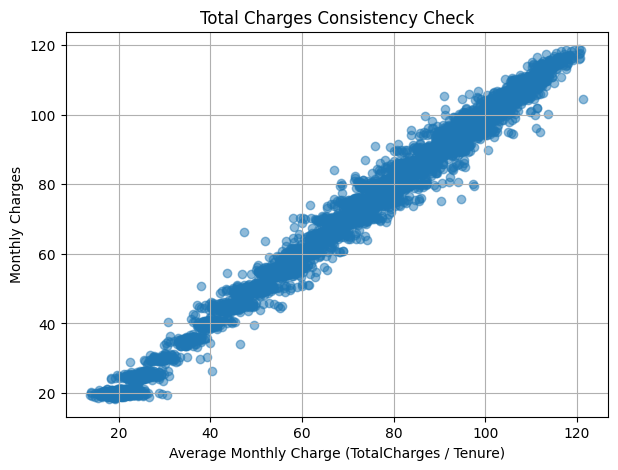

In [5]:
# ==========================================
# Data Type Validation and Conversion
# ==========================================

print("Original Data Types")
display(df.dtypes)

df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

df = df.dropna(subset=["TotalCharges"]).reset_index(drop=True)

# ==========================================
# Dataset Overview
# ==========================================

print(f"Dataset Shape: {df.shape}")
display(df.head())

print("\nMissing Values:")
display(df.isnull().sum())

print(f"\nDuplicate Records: {df.duplicated().sum()}")


# ==========================================
# Data Cleaning
# ==========================================

# Remove non-predictive features
df = df.drop(columns=["customerID", "PhoneService"])

# Convert target variable to binary
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0}).astype("int8")

# Replace redundant internet service categories
internet_features = [
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
]

for col in internet_features:
    df[col] = df[col].replace("No internet service", "No")


# ==========================================
# One-Hot Encoding
# ==========================================

categorical_cols = [
    "gender",
    "Partner",
    "Dependents",
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "Contract",
    "PaperlessBilling",
    "PaymentMethod",
]

df = pd.get_dummies(
    df,
    columns=categorical_cols,
    drop_first=True,
    dtype=int
)


# ==========================================
# Billing Consistency Check
# ==========================================

# Validate:
# TotalCharges ≈ MonthlyCharges × Tenure

mask = df["tenure"] > 0

plt.figure(figsize=(7, 5))

plt.scatter(
    df.loc[mask, "TotalCharges"] / df.loc[mask, "tenure"],
    df.loc[mask, "MonthlyCharges"],
    alpha=0.5,
)

plt.xlabel("Average Monthly Charge (TotalCharges / Tenure)")
plt.ylabel("Monthly Charges")
plt.title("Total Charges Consistency Check")
plt.grid(True)

plt.show()

<h1>3. Train-Test Split and Baseline Model</h1>

In [6]:
# ==========================================
# Train-Test Split
# ==========================================

X = df.drop(columns=["Churn"])
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE,
)

print(f"Training Samples : {len(X_train)}")
print(f"Testing Samples  : {len(X_test)}")


# ==========================================
# Feature Scaling
# ==========================================

num_cols = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges",
]

scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[num_cols] = scaler.fit_transform(X_train_scaled[num_cols])
X_test_scaled[num_cols] = scaler.transform(X_test_scaled[num_cols])


# ==========================================
# Utility Functions
# ==========================================

model_metrics_tracker = {}


def store_metrics(model_name, y_true, y_pred, y_proba):
    """Store evaluation metrics for model comparison."""

    model_metrics_tracker[model_name] = {
        "ROC-AUC": roc_auc_score(y_true, y_proba),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1-score": f1_score(y_true, y_pred),
    }


def print_model_report(model_name, y_true, y_pred, y_proba, best_params=None):
    """Print model evaluation report."""

    print("\n" + "=" * 50)
    print(f"MODEL: {model_name}")
    print("=" * 50)

    if best_params is not None:
        print("Best Hyperparameters:")
        print(best_params)

    print("\nConfusion Matrix")
    print(confusion_matrix(y_true, y_pred))

    print("\nClassification Report")
    print(classification_report(y_true, y_pred))

    print(f"ROC-AUC Score: {roc_auc_score(y_true, y_proba):.4f}")
    print("-" * 50)


# ==========================================
# Baseline Model
# ==========================================

log_reg_baseline = LogisticRegression(
    random_state=RANDOM_STATE,
    max_iter=1000,
)

log_reg_baseline.fit(X_train_scaled, y_train)

lr_y_pred = log_reg_baseline.predict(X_test_scaled)
lr_y_proba = log_reg_baseline.predict_proba(X_test_scaled)[:, 1]

store_metrics(
    "Logistic Regression (Baseline)",
    y_test,
    lr_y_pred,
    lr_y_proba,
)

print_model_report(
    "Logistic Regression (Baseline)",
    y_test,
    lr_y_pred,
    lr_y_proba,
)

Training Samples : 5625
Testing Samples  : 1407

MODEL: Logistic Regression (Baseline)

Confusion Matrix
[[918 115]
 [162 212]]

Classification Report
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1033
           1       0.65      0.57      0.60       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407

ROC-AUC Score: 0.8362
--------------------------------------------------


<h1>4. Hyperparameter Tuning and Model Comparison</h1>

<h2>Decision Tree</h2>

In [4]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
def evaluate_model(model, model_name, best_params=None):
    """Fits the model, predicts, and logs performance metrics."""
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    store_metrics(model_name, y_test, y_pred, y_proba)

    print_model_report(
        model_name,
        y_test,
        y_pred,
        y_proba,
        best_params
    )

def dt_objective(trial):
    params = {
        "max_depth": trial.suggest_int("max_depth", 3, 20),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 20),
        "criterion": trial.suggest_categorical("criterion", ["gini", "entropy"]),
        "random_state": RANDOM_STATE
    }
    
    model = DecisionTreeClassifier(**params)
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring="roc_auc", n_jobs=-1)
    return np.mean(scores)

# Optimize
dt_study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE)
)
dt_study.optimize(dt_objective, n_trials=100, show_progress_bar=True)

# Train & Evaluate Best Model
best_decision_tree = DecisionTreeClassifier(**dt_study.best_params, random_state=RANDOM_STATE)
evaluate_model(best_decision_tree, "Decision Tree", dt_study.best_params)

  0%|          | 0/100 [00:00<?, ?it/s]


MODEL: Decision Tree
Best Hyperparameters:
{'max_depth': 5, 'min_samples_split': 9, 'min_samples_leaf': 13, 'criterion': 'entropy'}

Confusion Matrix
[[914 119]
 [197 177]]

Classification Report
              precision    recall  f1-score   support

           0       0.82      0.88      0.85      1033
           1       0.60      0.47      0.53       374

    accuracy                           0.78      1407
   macro avg       0.71      0.68      0.69      1407
weighted avg       0.76      0.78      0.77      1407

ROC-AUC Score: 0.8159
--------------------------------------------------


<h2>Random Forest</h2>

In [5]:
def rf_objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 50, 300),
        "max_depth": trial.suggest_int("max_depth", 3, 20),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 20),
        "max_features": trial.suggest_categorical("max_features", ["sqrt", "log2", None]),
        "criterion": trial.suggest_categorical("criterion", ["gini", "entropy", "log_loss"]),
        "bootstrap": trial.suggest_categorical("bootstrap", [True, False]),
        "class_weight": trial.suggest_categorical("class_weight", [None, "balanced"]),
        "random_state": RANDOM_STATE,
        "n_jobs": -1
    }
    
    model = RandomForestClassifier(**params)
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring="roc_auc", n_jobs=-1)
    return scores.mean()

# Optimize
rf_study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE)
)
rf_study.optimize(rf_objective, n_trials=150, show_progress_bar=True)

# Train & Evaluate Best Model
best_random_forest = RandomForestClassifier(**rf_study.best_params, random_state=RANDOM_STATE, n_jobs=-1)
evaluate_model(best_random_forest, "Random Forest", rf_study.best_params)

  0%|          | 0/150 [00:00<?, ?it/s]


MODEL: Random Forest
Best Hyperparameters:
{'n_estimators': 256, 'max_depth': 9, 'min_samples_split': 3, 'min_samples_leaf': 13, 'max_features': 'log2', 'criterion': 'log_loss', 'bootstrap': True, 'class_weight': 'balanced'}

Confusion Matrix
[[763 270]
 [ 78 296]]

Classification Report
              precision    recall  f1-score   support

           0       0.91      0.74      0.81      1033
           1       0.52      0.79      0.63       374

    accuracy                           0.75      1407
   macro avg       0.72      0.77      0.72      1407
weighted avg       0.81      0.75      0.77      1407

ROC-AUC Score: 0.8411
--------------------------------------------------


<h2>XGBoost</h2>

In [6]:
def xgb_objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 600),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.005, 0.3, log=True),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "gamma": trial.suggest_float("gamma", 0.0, 5.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 10, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 10, log=True),
        "scale_pos_weight": trial.suggest_float("scale_pos_weight", 1.0, 3.5),
        "objective": "binary:logistic",
        "eval_metric": "auc",
        "tree_method": "hist",
        "random_state": RANDOM_STATE,
        "n_jobs": -1,
    }
    
    model = XGBClassifier(**params)
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring="roc_auc", n_jobs=-1)
    return scores.mean()

# Optimize
xgb_study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE)
)
xgb_study.optimize(xgb_objective, n_trials=200, show_progress_bar=True)

# Train & Evaluate Best Model
best_xgboost = XGBClassifier(
    **xgb_study.best_params,
    objective="binary:logistic",
    eval_metric="auc",
    tree_method="hist",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
evaluate_model(best_xgboost, "XGBoost", xgb_study.best_params)

  0%|          | 0/200 [00:00<?, ?it/s]


MODEL: XGBoost
Best Hyperparameters:
{'n_estimators': 359, 'max_depth': 3, 'learning_rate': 0.0464389320104237, 'subsample': 0.63287726077194, 'colsample_bytree': 0.6084235434632994, 'min_child_weight': 2, 'gamma': 4.791187755964521, 'reg_alpha': 0.01812365957045683, 'reg_lambda': 5.5533776303867, 'scale_pos_weight': 2.619680405211461}

Confusion Matrix
[[738 295]
 [ 75 299]]

Classification Report
              precision    recall  f1-score   support

           0       0.91      0.71      0.80      1033
           1       0.50      0.80      0.62       374

    accuracy                           0.74      1407
   macro avg       0.71      0.76      0.71      1407
weighted avg       0.80      0.74      0.75      1407

ROC-AUC Score: 0.8408
--------------------------------------------------


<h2>CatBoost</h2>

In [7]:
def cb_objective(trial):
    params = {
        "iterations": trial.suggest_int("iterations", 200, 800),
        "depth": trial.suggest_int("depth", 4, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1, 20),
        "random_strength": trial.suggest_float("random_strength", 0, 10),
        "bagging_temperature": trial.suggest_float("bagging_temperature", 0, 10),
        "border_count": trial.suggest_int("border_count", 32, 255),
        "loss_function": "Logloss",
        "eval_metric": "AUC",
        "random_seed": RANDOM_STATE,
        "verbose": 0,
    }
    
    model = CatBoostClassifier(**params)
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring="roc_auc", n_jobs=-1)
    return scores.mean()

# Optimize
cb_study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE)
)
cb_study.optimize(cb_objective, n_trials=150, show_progress_bar=True)

# Train & Evaluate Best Model
best_catboost = CatBoostClassifier(
    **cb_study.best_params,
    loss_function="Logloss",
    eval_metric="AUC",
    random_seed=RANDOM_STATE,
    logging_level="Silent",
)
evaluate_model(best_catboost, "CatBoost", cb_study.best_params)

  0%|          | 0/150 [00:00<?, ?it/s]


MODEL: CatBoost
Best Hyperparameters:
{'iterations': 640, 'depth': 4, 'learning_rate': 0.01493456734350036, 'l2_leaf_reg': 2.090897990697349, 'random_strength': 2.566472797946479, 'bagging_temperature': 3.102407373292428, 'border_count': 212}

Confusion Matrix
[[934  99]
 [180 194]]

Classification Report
              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1033
           1       0.66      0.52      0.58       374

    accuracy                           0.80      1407
   macro avg       0.75      0.71      0.73      1407
weighted avg       0.79      0.80      0.79      1407

ROC-AUC Score: 0.8439
--------------------------------------------------


<h2>LightGBM</h2>

In [8]:
def lgb_objective(trial):
    max_depth = trial.suggest_int("max_depth", 3, 12)
    max_leaves = min(131, 2 ** max_depth) 
    
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 800),
        "learning_rate": trial.suggest_float("learning_rate", 0.005, 0.3, log=True),
        "max_depth": max_depth,
        "num_leaves": trial.suggest_int("num_leaves", 7, max_leaves),
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 60),
        "min_split_gain": trial.suggest_float("min_split_gain", 0.0, 2.0),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 10, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 10, log=True),
        "scale_pos_weight": trial.suggest_float("scale_pos_weight", 1.0, 3.5),
        "objective": "binary",
        "metric": "auc",
        "random_state": RANDOM_STATE,
        "n_jobs": -1,
        "verbose": -1,
    }
    
    model = LGBMClassifier(**params)
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring="roc_auc", n_jobs=-1)
    return scores.mean()

# Optimize
lgb_study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE)
)
lgb_study.optimize(lgb_objective, n_trials=100, show_progress_bar=True)

# Train & Evaluate Best Model
best_lightgbm = LGBMClassifier(
    **lgb_study.best_params,
    objective="binary",
    metric="auc",
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=-1,
)
evaluate_model(best_lightgbm, "LightGBM", lgb_study.best_params)

  0%|          | 0/100 [00:00<?, ?it/s]


MODEL: LightGBM
Best Hyperparameters:
{'max_depth': 4, 'n_estimators': 418, 'learning_rate': 0.04686433464158939, 'num_leaves': 10, 'min_child_samples': 7, 'min_split_gain': 1.7113438324753945, 'subsample': 0.7828022512330842, 'colsample_bytree': 0.7766244865966714, 'reg_alpha': 2.086228966753728, 'reg_lambda': 6.474825673066824e-07, 'scale_pos_weight': 1.670188984405315}

Confusion Matrix
[[839 194]
 [112 262]]

Classification Report
              precision    recall  f1-score   support

           0       0.88      0.81      0.85      1033
           1       0.57      0.70      0.63       374

    accuracy                           0.78      1407
   macro avg       0.73      0.76      0.74      1407
weighted avg       0.80      0.78      0.79      1407

ROC-AUC Score: 0.8430
--------------------------------------------------


<h1>5. Threshold Optimization and Final Model Evaluation</h1>

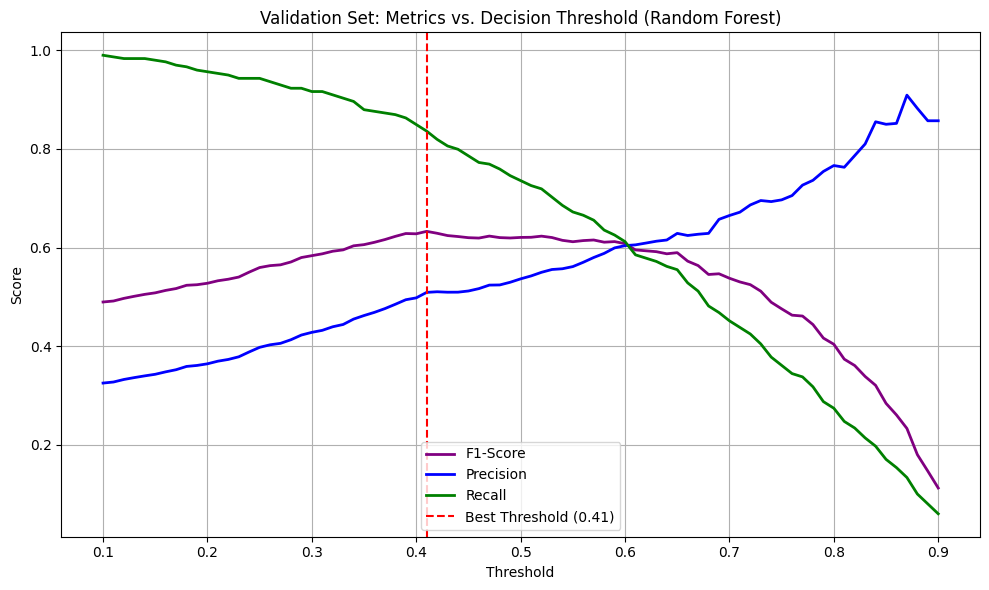


MODEL: Random Forest Final (Threshold: 0.41)

Confusion Matrix
[[674 359]
 [ 53 321]]

Classification Report
              precision    recall  f1-score   support

           0       0.93      0.65      0.77      1033
           1       0.47      0.86      0.61       374

    accuracy                           0.71      1407
   macro avg       0.70      0.76      0.69      1407
weighted avg       0.81      0.71      0.72      1407

ROC-AUC Score: 0.8411
--------------------------------------------------


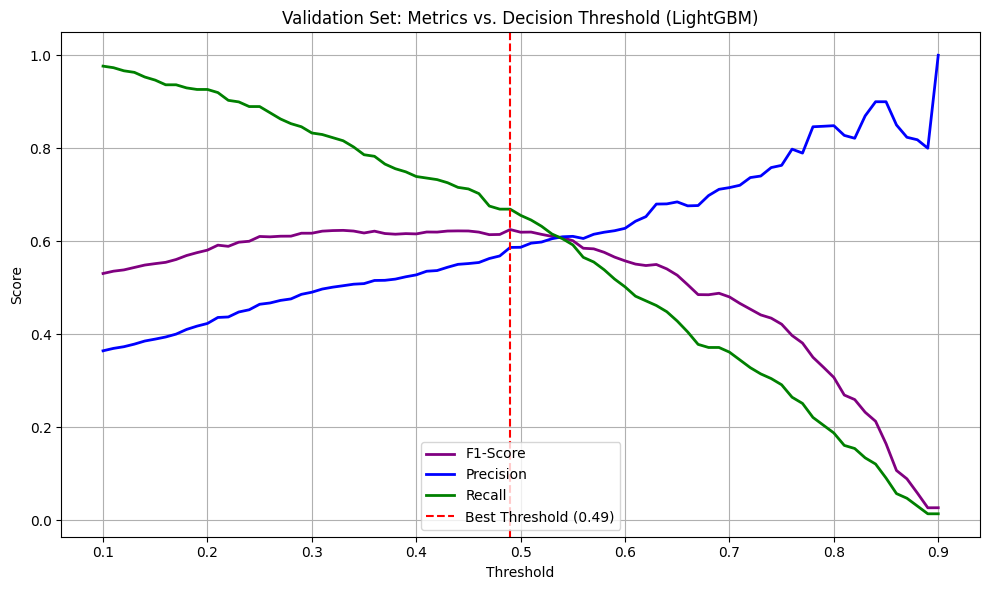


MODEL: LightGBM Final (Threshold: 0.49)

Confusion Matrix
[[835 198]
 [108 266]]

Classification Report
              precision    recall  f1-score   support

           0       0.89      0.81      0.85      1033
           1       0.57      0.71      0.63       374

    accuracy                           0.78      1407
   macro avg       0.73      0.76      0.74      1407
weighted avg       0.80      0.78      0.79      1407

ROC-AUC Score: 0.8430
--------------------------------------------------


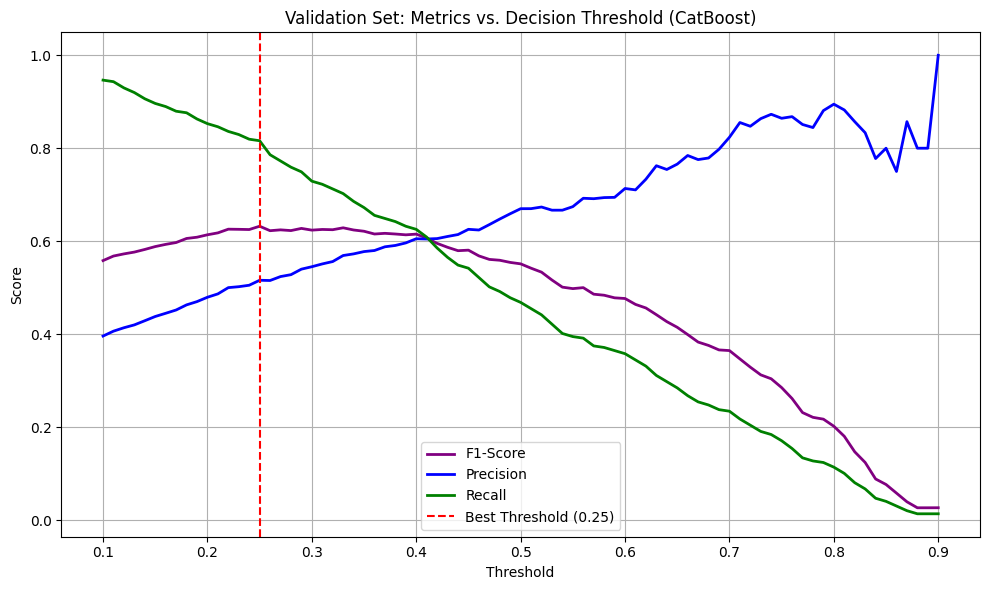


MODEL: CatBoost Final (Threshold: 0.25)

Confusion Matrix
[[711 322]
 [ 66 308]]

Classification Report
              precision    recall  f1-score   support

           0       0.92      0.69      0.79      1033
           1       0.49      0.82      0.61       374

    accuracy                           0.72      1407
   macro avg       0.70      0.76      0.70      1407
weighted avg       0.80      0.72      0.74      1407

ROC-AUC Score: 0.8439
--------------------------------------------------


Random Forest    0.41
XGBoost          0.56
LightGBM         0.49
CatBoost         0.25
Name: Optimal Threshold, dtype: float64

In [8]:
rf_params = {
    **rf_study.best_params,
    "random_state": RANDOM_STATE,
    "n_jobs": -1,
}

xgb_params = {
    **xgb_study.best_params,
    "objective": "binary:logistic",
    "eval_metric": "auc",
    "tree_method": "hist",
    "random_state": RANDOM_STATE,
    "n_jobs": -1,
}

lgb_params = {
    **lgb_study.best_params,
    "objective": "binary",
    "metric": "auc",
    "random_state": RANDOM_STATE,
    "n_jobs": -1,
    "verbose": -1,
}

cb_params = {
    **cb_study.best_params,
    "loss_function": "Logloss",
    "eval_metric": "AUC",
    "random_seed": RANDOM_STATE,
    "logging_level": "Silent",
}


def tune_threshold(model, model_name, X_train_full, y_train_full):
    X_tr, X_val, y_tr, y_val = train_test_split(
        X_train_full,
        y_train_full,
        test_size=0.2,
        random_state=RANDOM_STATE,
        stratify=y_train_full,
    )

    model.fit(X_tr, y_tr)
    val_y_proba = model.predict_proba(X_val)[:, 1]

    thresholds = np.arange(0.1, 0.91, 0.01)
    precisions, recalls, f1_scores = [], [], []
    best_threshold, best_f1 = 0.5, 0.0

    for threshold in thresholds:
        val_preds = (val_y_proba >= threshold).astype(int)
        precision = precision_score(y_val, val_preds, zero_division=0)
        recall = recall_score(y_val, val_preds, zero_division=0)
        f1 = f1_score(y_val, val_preds, zero_division=0)

        precisions.append(precision)
        recalls.append(recall)
        f1_scores.append(f1)

        if f1 > best_f1:
            best_f1 = f1
            best_threshold = threshold

    plt.figure(figsize=(10, 6))
    plt.plot(thresholds, f1_scores, color="purple", linewidth=2, label="F1-Score")
    plt.plot(thresholds, precisions, color="blue", linewidth=2, label="Precision")
    plt.plot(thresholds, recalls, color="green", linewidth=2, label="Recall")
    plt.axvline(
        best_threshold,
        color="red",
        linestyle="--",
        linewidth=1.5,
        label=f"Best Threshold ({best_threshold:.2f})",
    )
    plt.title(f"Validation Set: Metrics vs. Decision Threshold ({model_name})")
    plt.xlabel("Threshold")
    plt.ylabel("Score")
    plt.legend(loc="lower center")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    return best_threshold


def evaluate_final_model(
    model,
    model_name,
    threshold,
    X_train_full,
    y_train_full,
    X_test_full,
    y_test_full,
):
    model.fit(X_train_full, y_train_full)

    y_proba = model.predict_proba(X_test_full)[:, 1]
    y_pred = (y_proba >= threshold).astype(int)

    store_metrics(model_name, y_test_full, y_pred, y_proba)
    print_model_report(
        f"{model_name} Final (Threshold: {threshold:.2f})",
        y_test_full,
        y_pred,
        y_proba,
    )
    return model, y_pred, y_proba


rf_threshold = tune_threshold(
    RandomForestClassifier(**rf_params), "Random Forest", X_train, y_train
)
final_rf, rf_y_pred, rf_y_proba = evaluate_final_model(
    RandomForestClassifier(**rf_params),
    "Random Forest",
    rf_threshold,
    X_train,
    y_train,
    X_test,
    y_test,
)

lgb_threshold = tune_threshold(
    LGBMClassifier(**lgb_params), "LightGBM", X_train, y_train
)
final_lgb, lgb_y_pred, lgb_y_proba = evaluate_final_model(
    LGBMClassifier(**lgb_params),
    "LightGBM",
    lgb_threshold,
    X_train,
    y_train,
    X_test,
    y_test,
)

cb_threshold = tune_threshold(
    CatBoostClassifier(**cb_params), "CatBoost", X_train, y_train
)
final_cb, cb_y_pred, cb_y_proba = evaluate_final_model(
    CatBoostClassifier(**cb_params),
    "CatBoost",
    cb_threshold,
    X_train,
    y_train,
    X_test,
    y_test,
)

optimal_thresholds = {
    "Random Forest": rf_threshold,
    "XGBoost": xgb_threshold,
    "LightGBM": lgb_threshold,
    "CatBoost": cb_threshold,
}

display(pd.Series(optimal_thresholds, name="Optimal Threshold"))

<h1>6. Model Interpretability with SHAP</h1>

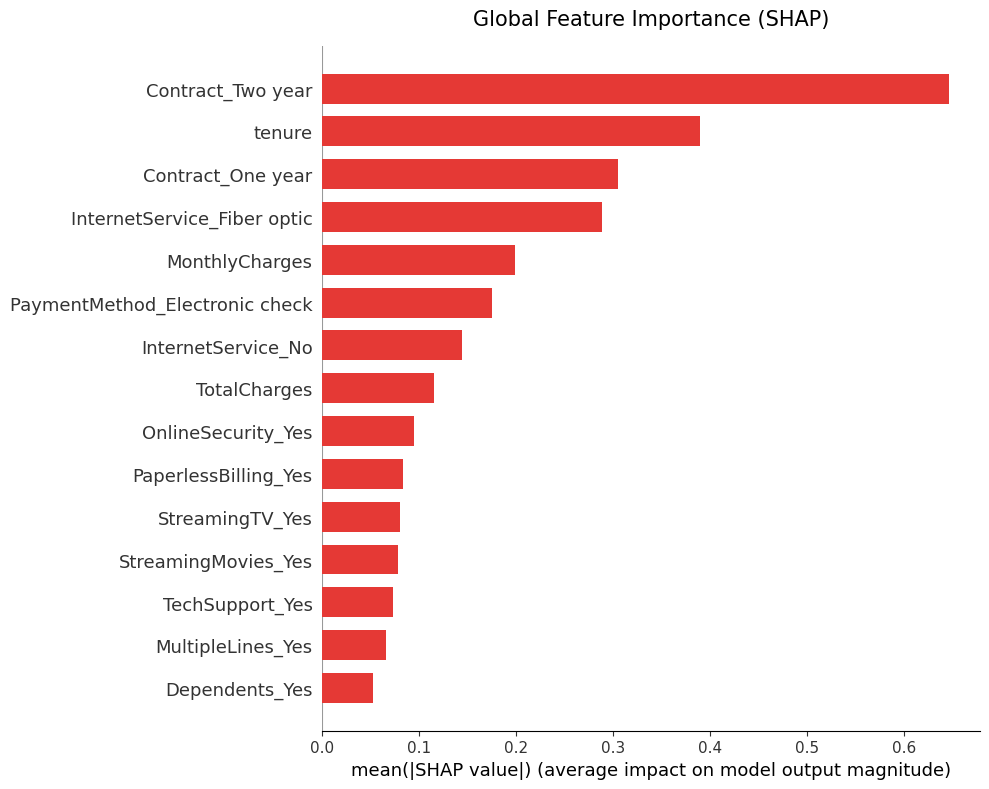

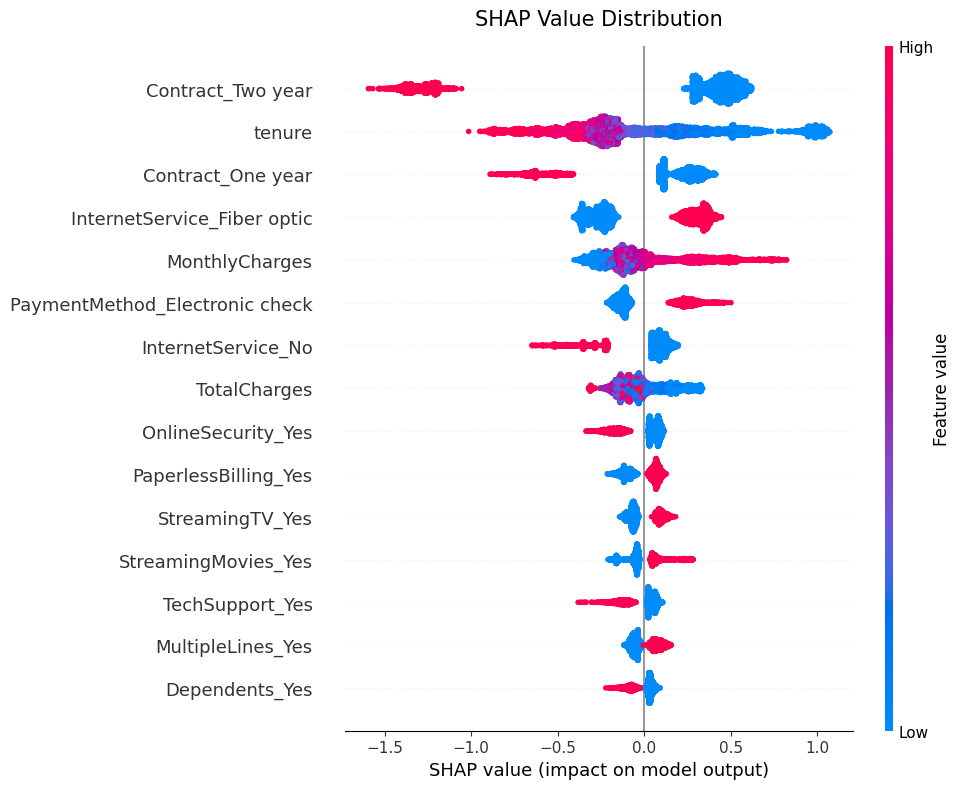

Saved successfully:
 • shap_feature_importance.png
 • shap_beeswarm_plot.png


In [9]:
# Configuration constants
MAX_DISPLAY = 15
FIG_SIZE = (10, 8)

# Initialize explainer and calculate SHAP values
explainer = shap.TreeExplainer(final_lgb)
shap_values = explainer(X_train)

# 1. Global Feature Importance (Bar Plot)
shap.summary_plot(
    shap_values,
    X_train,
    plot_type="bar",
    max_display=MAX_DISPLAY,
    color="#E53935",
    show=False,
)
plt.gcf().set_size_inches(FIG_SIZE)
plt.title("Global Feature Importance (SHAP)", fontsize=15, pad=15)
plt.tight_layout()
plt.savefig("shap_feature_importance.png", dpi=300, bbox_inches="tight")
plt.show()  # Display in notebook AFTER saving

# 2. SHAP Value Distribution (Beeswarm Plot)
shap.summary_plot(
    shap_values,
    X_train,
    max_display=MAX_DISPLAY,
    show=False,
)
plt.gcf().set_size_inches(FIG_SIZE)
plt.title("SHAP Value Distribution", fontsize=15, pad=15)
plt.tight_layout()
plt.savefig("shap_beeswarm_plot.png", dpi=300, bbox_inches="tight")
plt.show()  # Display in notebook AFTER saving

print("Saved successfully:")
print(" • shap_feature_importance.png")
print(" • shap_beeswarm_plot.png")

<h1>7. Save Production Model</h1>

In [10]:
production_artifact = {
    "model": final_lgb,
    "threshold": lgb_threshold,
    "features": X_train.columns.tolist(),
}

artifact_path = "lightgbm_churn_production.pkl"

joblib.dump(
    production_artifact,
    artifact_path,
    compress=3,
)

print(f"Production artifact saved to '{artifact_path}'.")

Production artifact saved to 'lightgbm_churn_production.pkl'.
